In [1]:
# imports

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import transforms, models
from torchvision.models import EfficientNet_B0_Weights
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# setup paths

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "processed"

MODEL_PATH = DATA_DIR / "best_model_augmented.pth"
VAL_CSV = DATA_DIR / "val.csv"
LABEL_MAP_PATH = DATA_DIR / "label_map.json"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)

Device: cuda


In [3]:
# load label map

with open(LABEL_MAP_PATH) as f:
    label_map = json.load(f)

idx_to_label = {v: k for k, v in label_map.items()}

print(idx_to_label)

{0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'}


In [4]:
# define model architecture

class MultiModalNet(nn.Module):
    def __init__(self, meta_input_dim, num_classes=7):
        super().__init__()

        self.backbone = models.efficientnet_b0(
            weights=EfficientNet_B0_Weights.DEFAULT
        )
        self.backbone.classifier = nn.Identity()

        image_feat_dim = 1280

        self.meta_net = nn.Sequential(
            nn.Linear(meta_input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(image_feat_dim + 32, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, image, metadata):
        img_feat = self.backbone(image)
        meta_feat = self.meta_net(metadata)
        combined = torch.cat([img_feat, meta_feat], dim=1)
        return self.classifier(combined)

In [5]:
# load validation data

val_df = pd.read_csv(VAL_CSV)

meta_cols = val_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
meta_cols.remove("label")

print("Metadata columns:", meta_cols)

Metadata columns: ['age', 'sex', 'width', 'height', 'localization_abdomen', 'localization_acral', 'localization_back', 'localization_chest', 'localization_ear', 'localization_face', 'localization_foot', 'localization_genital', 'localization_hand', 'localization_lower extremity', 'localization_neck', 'localization_scalp', 'localization_trunk', 'localization_unknown', 'localization_upper extremity']


In [6]:
# define transform

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
# load model

meta_dim = len(meta_cols)

model = MultiModalNet(meta_dim)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


/tmp/ipykernel_190897/2046747511.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))


In [8]:
# val inference

all_preds = []
all_labels = []

with torch.no_grad():
    for i in range(len(val_df)):
        row = val_df.iloc[i]

        image = Image.open(row["image_path"]).convert("RGB")
        image = val_transform(image).unsqueeze(0).to(DEVICE)

        metadata = torch.tensor(
            row[meta_cols].values.astype(np.float32)
        ).unsqueeze(0).to(DEVICE)

        outputs = model(image, metadata)
        pred = torch.argmax(outputs, dim=1).item()

        all_preds.append(pred)
        all_labels.append(row["label"])

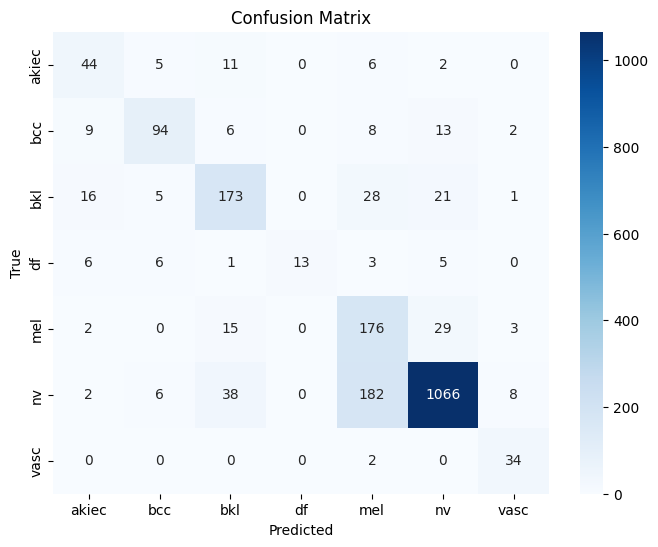

In [9]:
# confusion matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=idx_to_label.values(),
            yticklabels=idx_to_label.values())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [10]:
# classification report

print(classification_report(
    all_labels,
    all_preds,
    target_names=list(idx_to_label.values())
))

              precision    recall  f1-score   support

       akiec       0.56      0.65      0.60        68
         bcc       0.81      0.71      0.76       132
         bkl       0.71      0.71      0.71       244
          df       1.00      0.38      0.55        34
         mel       0.43      0.78      0.56       225
          nv       0.94      0.82      0.87      1302
        vasc       0.71      0.94      0.81        36

    accuracy                           0.78      2041
   macro avg       0.74      0.71      0.69      2041
weighted avg       0.83      0.78      0.80      2041



In [11]:
# visualize random predictions

def show_prediction(index):
    row = val_df.iloc[index]
    
    image = Image.open(row["image_path"]).convert("RGB")
    image_tensor = val_transform(image).unsqueeze(0).to(DEVICE)
    
    metadata = torch.tensor(
        row[meta_cols].values.astype(np.float32)
    ).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(image_tensor, metadata)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    plt.imshow(image)
    plt.title(f"True: {idx_to_label[row['label']]} | Pred: {idx_to_label[pred]}")
    plt.axis("off")
    plt.show()

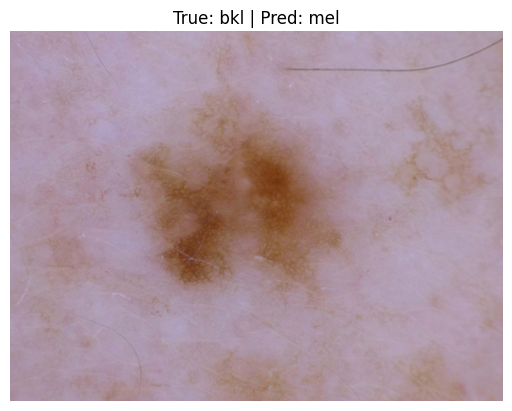

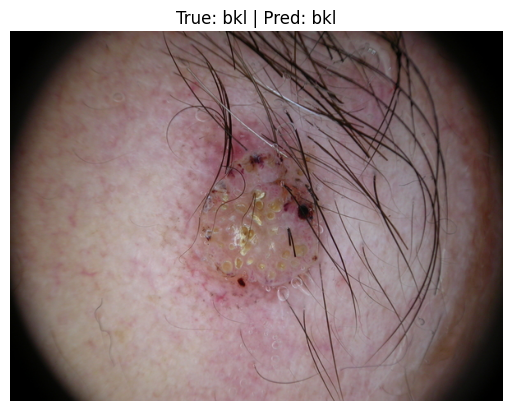

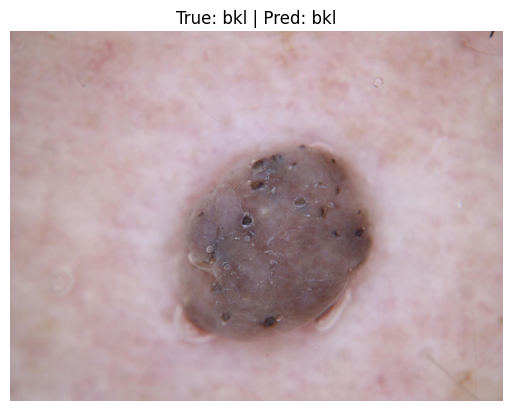

In [12]:
show_prediction(10)
show_prediction(50)
show_prediction(100)

In [13]:
# save results to CSV

from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
from pathlib import Path
import os

PROJECT_ROOT = Path().resolve().parent
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# Convert classification report to dict
report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=list(label_map.keys()),
    output_dict=True
)

accuracy = accuracy_score(all_labels, all_preds)

# Flatten report
row = {
    "model_name": "augmented_model",  # change per experiment
    "accuracy": accuracy,
    "macro_f1": report_dict["macro avg"]["f1-score"],
    "weighted_f1": report_dict["weighted avg"]["f1-score"]
}

# Add per-class metrics
for cls in label_map.keys():
    row[f"{cls}_precision"] = report_dict[cls]["precision"]
    row[f"{cls}_recall"] = report_dict[cls]["recall"]
    row[f"{cls}_f1"] = report_dict[cls]["f1-score"]
    row[f"{cls}_support"] = report_dict[cls]["support"]

results_path = RESULTS_DIR / "experiments.csv"

if results_path.exists():
    df_results = pd.read_csv(results_path)
    df_results = pd.concat([df_results, pd.DataFrame([row])], ignore_index=True)
else:
    df_results = pd.DataFrame([row])

df_results.to_csv(results_path, index=False)

print("Results saved to:", results_path)

Results saved to: /home/saber/Wox/ACV/Case_Study/results/experiments.csv
